In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [47]:
df = pd.read_csv('/content/placement.csv')

In [48]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package in LPA')

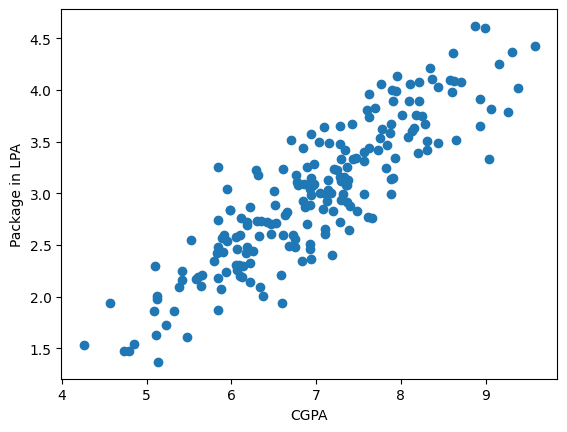

In [49]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel("Package in LPA")

In [50]:
df.shape

(200, 2)

In [51]:
X=df.iloc[:,0:1]
y=df.iloc[:,-1]
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [52]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [53]:
X_train.shape

(160, 1)

In [54]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()

lr.fit(X_train,y_train)


LinearRegression()

Text(0, 0.5, 'Package in LPA')

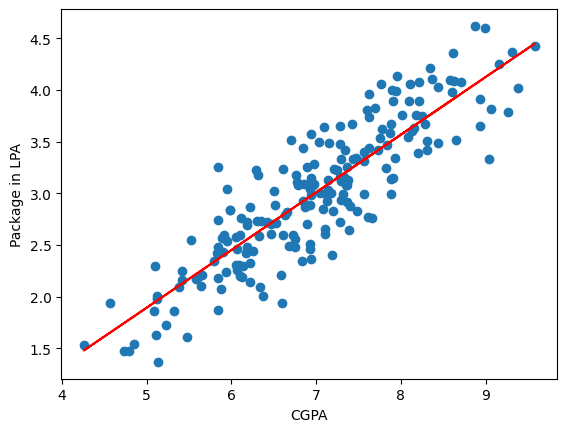

In [55]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train['cgpa'],lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel("Package in LPA")

In [63]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

In [57]:
y_pred = lr.predict(X_test)

In [58]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [59]:
print("MAE",mean_absolute_error(y_pred,y_test))

MAE 0.2884710931878175


In [60]:
print("MSE",mean_squared_error(y_pred,y_test))

MSE 0.12129235313495527


In [61]:
print("RMSE",root_mean_squared_error(y_pred,y_test))

RMSE 0.34827051717731616


In [64]:
print("R2",r2_score(y_pred,y_test))
r2=r2_score(y_pred,y_test)

R2 0.6626575570753073


In [65]:
#Ajusted R2 Score
a=1-(((1-r2)*(X_test.shape[0]-1)))/((X_test.shape[0]-1-1))

print("AR2",a)

AR2 0.6537801243667627


In [96]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.674034,3.26
1,5.12,0.843679,1.98
2,7.82,0.000467,3.25
3,7.42,0.159521,3.67
4,6.94,0.026008,3.57


Text(0, 0.5, 'Package in LPA')

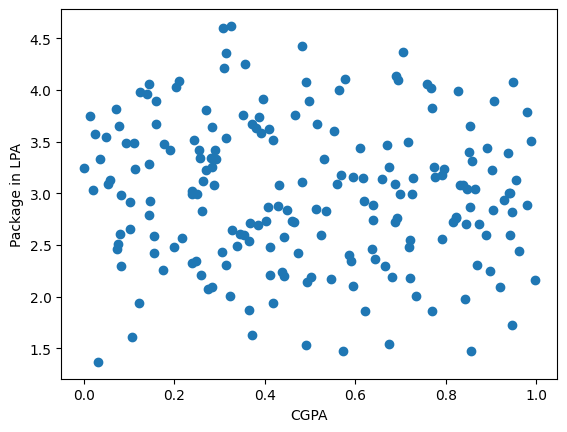

In [97]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('CGPA')
plt.ylabel("Package in LPA")

In [98]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [99]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [100]:
lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred=lr.predict(X_test)

In [101]:
print("R2",r2_score(y_pred,y_test))
r2=r2_score(y_pred,y_test)

R2 0.6652183323668848


In [80]:
a=1-(((1-r2)*(X_test.shape[0]-1)))/((X_test.shape[0]-1-1))

print("AR2",a)

AR2 0.6534945645329406


In [84]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [85]:
new_df2.sample(5)

,cgpa,iq,package
161,7.30,3.03,3.33
5,7.89,2.19,2.99
123,5.10,2.30,2.30
165,8.21,2.88,4.08
50,9.58,5.33,4.43


Text(0, 0.5, 'Package(in lpa)')

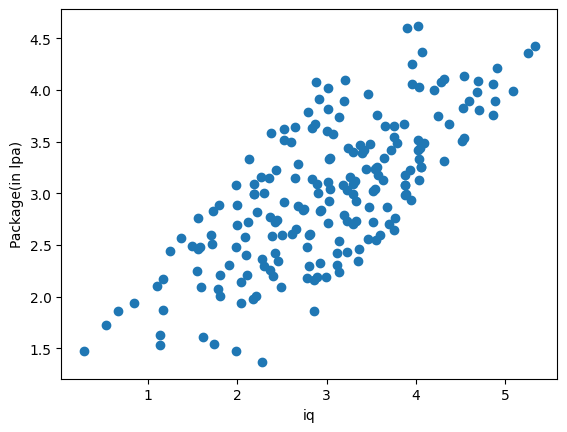

In [86]:

plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [91]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [92]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [93]:

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [94]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8147700285411386


In [95]:

1 - ((1-r2)*(40-1)/(40-1-2))

0.8047575976514704